## EfficientNet-V2-S + ConvNeXt Fusion (Multimodal Ensemble)

This notebook implements a **feature-level fusion** of two pretrained backbones:
- **EfficientNet-V2-S** (torchvision) — compound-scaled CNN with depthwise convolutions
- **ConvNeXt-Small** (HuggingFace) — transformer-inspired CNN with large kernels + LayerNorm

Both backbones process the **same image** independently. Their feature vectors are **concatenated** and passed through a shared fusion head for classification.

```
Image ──► EfficientNet-V2-S (frozen except last 3 blocks) ──► feature_eff (1280-d)
                                                                              │
                                                          ── concat ──► Fusion Head ──► num_classes
                                                                              │
Image ──► ConvNeXt-Small    (frozen except stages 2 & 3) ──► feature_cnx (768-d)
```

In [1]:
!pip install matplotlib scikit-learn transformers

# Connecting to Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing necessary libraries

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from transformers import get_cosine_schedule_with_warmup
from transformers import ConvNextModel, ConvNextImageProcessor

# Loading the ConvNeXt processor

In [5]:
convnext_model_name = "facebook/convnext-small-224"
processor = ConvNextImageProcessor.from_pretrained(convnext_model_name)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

# Transforms

EfficientNet-V2-S uses 260×260, ConvNeXt uses 224×224.
We resize to 260×260 so both models can share the same dataloader — ConvNeXt's processor will handle its own resize internally.

In [6]:
IMG_SIZE = 260

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.2),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

# Dataset class

Returns **two tensors per sample**:
- `pixel_values_eff` — normalized for EfficientNet (ImageNet mean/std, 260×260)
- `pixel_values_cnx` — processed by ConvNeXt processor (224×224)

Both come from the same augmented PIL image so augmentations are shared.

In [7]:
eff_normalize = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class FusionDataset(Dataset):
    def __init__(self, data_dir, processor, transform=None):
        self.dataset   = ImageFolder(root=data_dir, transform=transform)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        pil_image, label = self.dataset[idx]

        # EfficientNet branch
        pixel_eff = eff_normalize(pil_image)

        # ConvNeXt branch
        enc = self.processor(images=pil_image, return_tensors='pt')
        pixel_cnx = enc['pixel_values'].squeeze(0)

        return {
            'pixel_values_eff': pixel_eff,
            'pixel_values_cnx': pixel_cnx,
            'labels': torch.tensor(label)
        }

In [9]:
train_path = "/content/drive/MyDrive/dataset/train"
test_path  = "/content/drive/MyDrive/dataset/val"

train_dataset = FusionDataset(data_dir=train_path, transform=train_transforms, processor=processor)
test_dataset  = FusionDataset(data_dir=test_path,  transform=val_transforms,   processor=processor)

class_to_idx = train_dataset.dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
print(idx_to_class)

{0: 'F_Breakage', 1: 'F_Crushed', 2: 'F_Normal', 3: 'R_Breakage', 4: 'R_Crushed', 5: 'R_Normal'}


# Visualising the train/val split

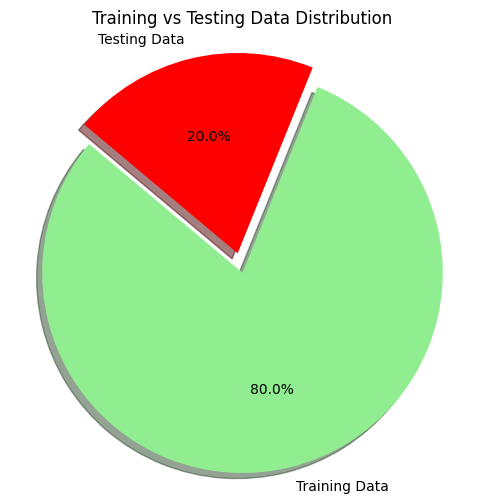

In [10]:
labels  = ['Training Data', 'Testing Data']
sizes   = [len(train_dataset), len(test_dataset)]
colors  = ['lightgreen', 'red']
explode = (0.1, 0)
plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Training vs Testing Data Distribution')
plt.axis('equal')
plt.show()

# Class distribution

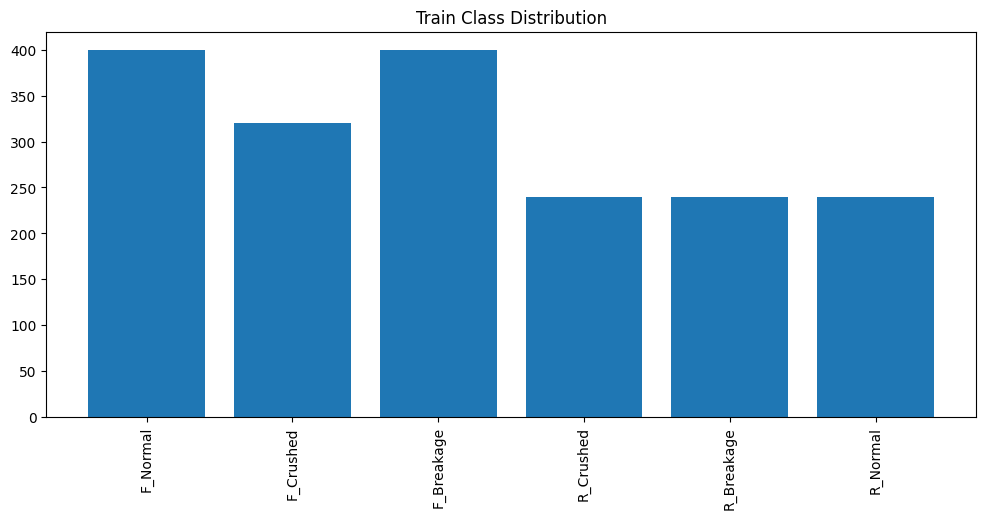

In [11]:
def plot_class_distribution(data_path):
    classes = os.listdir(data_path)
    counts  = []
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if os.path.isdir(cls_path):
            counts.append(len(os.listdir(cls_path)))
    plt.figure(figsize=(12, 5))
    plt.bar(classes, counts)
    plt.xticks(rotation=90)
    plt.title("Train Class Distribution")
    plt.show()

plot_class_distribution("/content/drive/MyDrive/dataset/train")

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
eval_loader  = DataLoader(test_dataset,  batch_size=32,
                          num_workers=2, pin_memory=True, persistent_workers=True)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Model — EfficientNet-V2-S + ConvNeXt-Small Fusion

## Architecture
```
Image ──► EfficientNet-V2-S backbone  ──► avgpool ──► (1280,)
                                                           ↓
                                                       concat → (2048,)
                                                           ↓
                                                     Fusion Head
                                                           ↓
                                                    num_classes logits
                                                           ↑
Image ──► ConvNeXt-Small backbone     ──► avgpool ──► (768,)
```

## Freezing strategy
- **EfficientNet**: freeze all → unfreeze features[5], [6], [7]
- **ConvNeXt**: freeze all → unfreeze stages[2], stages[3], layernorm

In [14]:
class FusionClassifier(nn.Module):
    def __init__(self, num_classes, convnext_model_name="facebook/convnext-small-224"):
        super().__init__()

        # EfficientNet-V2-S backbone
        eff = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)

        for param in eff.parameters():
            param.requires_grad = False

        for param in eff.features[5].parameters():
            param.requires_grad = True
        for param in eff.features[6].parameters():
            param.requires_grad = True
        for param in eff.features[7].parameters():
            param.requires_grad = True

        self.eff_features = eff.features
        self.eff_avgpool  = eff.avgpool
        self.eff_out_dim  = eff.classifier[1].in_features

        # ConvNeXt-Small backbone
        cnx = ConvNextModel.from_pretrained(convnext_model_name)

        for param in cnx.parameters():
            param.requires_grad = False

        for param in cnx.encoder.stages[2].parameters():
            param.requires_grad = True
        for param in cnx.encoder.stages[3].parameters():
            param.requires_grad = True
        for param in cnx.layernorm.parameters():
            param.requires_grad = True

        self.cnx_backbone = cnx
        self.cnx_out_dim  = 768

        # Fusion head
        fused_dim = self.eff_out_dim + self.cnx_out_dim
        self.fusion_head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(fused_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, pixel_values_eff, pixel_values_cnx):
        x_eff = self.eff_features(pixel_values_eff)
        x_eff = self.eff_avgpool(x_eff)
        x_eff = torch.flatten(x_eff, 1)

        cnx_out = self.cnx_backbone(
            pixel_values=pixel_values_cnx,
            return_dict=True
        )
        x_cnx = cnx_out.pooler_output

        fused  = torch.cat([x_eff, x_cnx], dim=1)
        logits = self.fusion_head(fused)

        return logits

In [15]:
model = FusionClassifier(
    num_classes=len(class_to_idx),
    convnext_model_name=convnext_model_name
).to(device)

print(f"EfficientNet output dim : {model.eff_out_dim}")
print(f"ConvNeXt output dim     : {model.cnx_out_dim}")
print(f"Fused dim               : {model.eff_out_dim + model.cnx_out_dim}")
print(f"Num classes             : {len(class_to_idx)}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 130MB/s]


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

ConvNextModel LOAD REPORT from: facebook/convnext-small-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


EfficientNet output dim : 1280
ConvNeXt output dim     : 768
Fused dim               : 2048
Num classes             : 6
Total trainable parameters: 67,759,054


# Loss, Optimizer

**5-group differential learning rates**
- EfficientNet features[5] → `1e-5` (earliest unfrozen block)
- EfficientNet features[6, 7] → `3e-5`
- ConvNeXt stages[2, 3] + layernorm → `3e-5`
- Fusion head → `1e-4` (trains from scratch, needs highest LR)

In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW([
    {"params": model.eff_features[5].parameters(), "lr": 1e-5},
    {"params": model.eff_features[6].parameters(), "lr": 3e-5},
    {"params": model.eff_features[7].parameters(), "lr": 3e-5},

    {"params": model.cnx_backbone.encoder.stages[2].parameters(), "lr": 3e-5},
    {"params": model.cnx_backbone.encoder.stages[3].parameters(), "lr": 3e-5},
    {"params": model.cnx_backbone.layernorm.parameters(),          "lr": 3e-5},

    {"params": model.fusion_head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

# Early Stopping

In [17]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter    = 0

# Training Function

In [18]:
def train_model(
    model,
    epochs,
    train_loader,
    eval_loader,
    optimizer,
    criterion,
    device,
    patience=7,
    checkpoint_model_name="model"
):

    print("Starting training...")
    print(f"Epochs: {epochs} | Device: {device}")
    print("-" * 60)

    # ------------------------- SCHEDULER -------------------------
    num_training_steps = epochs * len(train_loader)
    num_warmup_steps   = int(0.1 * num_training_steps)

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    early_stopping = EarlyStopping(patience=patience)

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    best_acc = 0.0

    # ------------------------- TRAIN LOOP -------------------------
    for epoch in range(epochs):

        # --------------------- TRAIN ---------------------
        model.train()
        running_loss, correct, total = 0, 0, 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):

            images_eff = batch['pixel_values_eff'].to(device)
            images_cnx = batch['pixel_values_cnx'].to(device)
            labels     = batch['labels'].to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images_eff, images_cnx)

            loss = criterion(logits, labels)
            loss.backward()

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            preds  = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100 * correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # --------------------- VALIDATION ---------------------
        model.eval()
        val_running_loss, val_correct, val_total = 0, 0, 0

        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in tqdm(eval_loader, desc=f"Epoch {epoch+1} Validation"):

                images_eff = batch['pixel_values_eff'].to(device)
                images_cnx = batch['pixel_values_cnx'].to(device)
                labels     = batch['labels'].to(device)

                logits = model(images_eff, images_cnx)

                loss = criterion(logits, labels)
                val_running_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(eval_loader)
        val_acc  = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Results "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )
        print("-" * 60)

        # --------------------- SAVE BEST MODEL (BY ACCURACY) ---------------------
        if val_acc > best_acc:
            best_acc = val_acc

            os.makedirs("checkpoints", exist_ok=True)

            torch.save({
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch":                epoch,
                "val_acc":              val_acc
            }, f"checkpoints/{checkpoint_model_name}.pt")

            print(f"Best model saved (Acc: {val_acc:.2f}%)")

        # --------------------- EARLY STOPPING ---------------------
        early_stopping(val_acc)

        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return (
        train_losses,
        train_accs,
        val_losses,
        val_accs,
        all_preds,
        all_labels
    )

# Train Model

In [19]:
train_losses, train_accuracy, eval_losses, eval_accuracies, all_preds, all_labels = train_model(
    model                 = model,
    train_loader          = train_loader,
    eval_loader           = eval_loader,
    optimizer             = optimizer,
    criterion             = criterion,
    device                = device,
    epochs                = 100,
    patience              = 7,
    checkpoint_model_name = 'best_fusion_model'
)

Starting training...
Epochs: 100 | Device: cuda
------------------------------------------------------------


Epoch 1 Validation: 100%|██████████| 15/15 [01:22<00:00,  5.49s/it]


Results Train Loss: 1.8266 | Train Acc: 20.49% || Val Loss: 1.7414 | Val Acc: 27.17%
------------------------------------------------------------
Best model saved (Acc: 27.17%)


Epoch 2 Validation: 100%|██████████| 15/15 [00:12<00:00,  1.23it/s]


Results Train Loss: 1.7159 | Train Acc: 29.29% || Val Loss: 1.5648 | Val Acc: 38.04%
------------------------------------------------------------
Best model saved (Acc: 38.04%)


...

Results Train Loss: 0.4457 | Train Acc: 99.57% || Val Loss: 0.9102 | Val Acc: 83.91%
------------------------------------------------------------
  EarlyStopping: 5/7


Epoch 28 Validation: 100%|██████████| 15/15 [00:09<00:00,  1.62it/s]


Results Train Loss: 0.4431 | Train Acc: 99.51% || Val Loss: 0.9279 | Val Acc: 83.48%
------------------------------------------------------------
  EarlyStopping: 6/7


Epoch 29 Validation: 100%|██████████| 15/15 [00:09<00:00,  1.56it/s]

Results Train Loss: 0.4438 | Train Acc: 99.57% || Val Loss: 0.9231 | Val Acc: 82.39%
------------------------------------------------------------
  EarlyStopping: 7/7
Early stopping at epoch 29


# Plotting the loss and accuracy

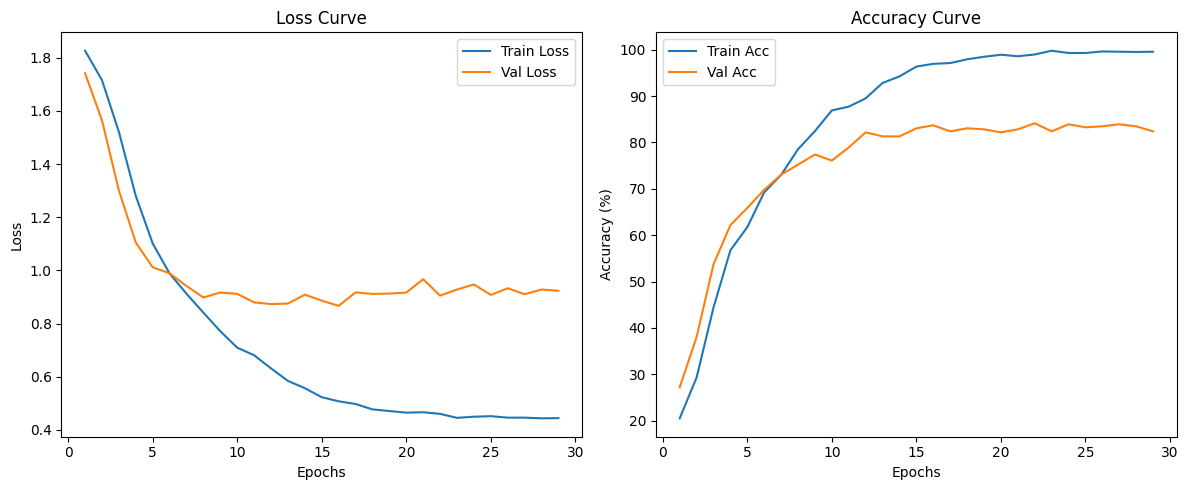

In [20]:
def plot_training_curves(train_losses, eval_losses, train_acc, eval_acc):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, eval_losses,  label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, eval_acc,  label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(
    train_losses,
    eval_losses,
    train_accuracy,
    eval_accuracies
)

# Confusion Matrix & Classification Report

In [21]:
def print_classification_report(all_labels, all_preds):
    class_names = train_dataset.dataset.classes
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
    print(report)

def plot_confusion_matrix_normalized(all_labels, all_preds):
    class_names = train_dataset.dataset.classes
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

ConvNextModel LOAD REPORT from: facebook/convnext-small-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best model loaded from checkpoints/best_fusion_model.pt (Validation Accuracy: 84.13%) at epoch 22


Making predictions on eval_loader: 100%|██████████| 15/15 [00:09<00:00,  1.65it/s]



--- Classification Report (from loaded model) ---
              precision    recall  f1-score   support

  F_Breakage       0.86      0.86      0.86       100
   F_Crushed       0.78      0.78      0.78        80
    F_Normal       0.91      0.92      0.92       100
  R_Breakage       0.83      0.80      0.81        60
   R_Crushed       0.74      0.82      0.78        60
    R_Normal       0.89      0.83      0.86        60

    accuracy                           0.84       460
   macro avg       0.84      0.83      0.83       460
weighted avg       0.84      0.84      0.84       460


--- Confusion Matrix (from loaded model) ---


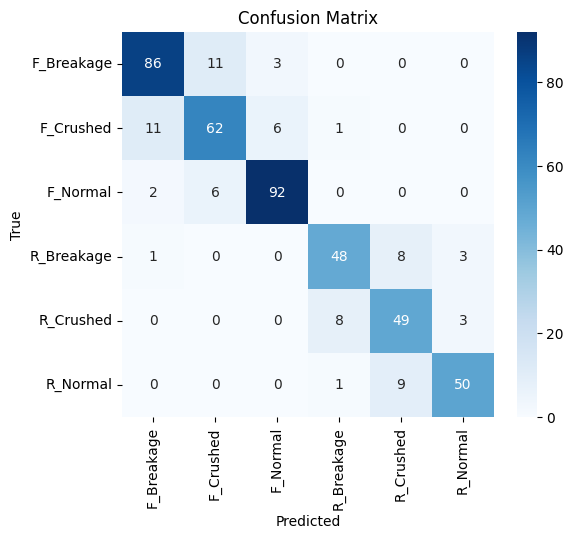

In [22]:
loaded_model = FusionClassifier(
    num_classes=len(class_to_idx),
    convnext_model_name=convnext_model_name
).to(device)

checkpoint_path = "checkpoints/best_fusion_model.pt"
checkpoint = torch.load(checkpoint_path)
loaded_model.load_state_dict(checkpoint['model_state_dict'])

print(f"Best model loaded from {checkpoint_path} (Validation Accuracy: {checkpoint['val_acc']:.2f}%) at epoch {checkpoint['epoch']+1}")

loaded_model.eval()

all_labels_loaded_model = []
all_preds_loaded_model = []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Making predictions on eval_loader"):
        images_eff = batch['pixel_values_eff'].to(device)
        images_cnx = batch['pixel_values_cnx'].to(device)
        labels     = batch['labels'].to(device)

        logits = loaded_model(images_eff, images_cnx)
        preds = torch.argmax(logits, dim=1)

        all_labels_loaded_model.extend(labels.cpu().numpy())
        all_preds_loaded_model.extend(preds.cpu().numpy())

print("\n--- Classification Report (from loaded model) ---")
print_classification_report(all_labels_loaded_model, all_preds_loaded_model)

print("\n--- Confusion Matrix (from loaded model) ---")
plot_confusion_matrix_normalized(all_labels_loaded_model, all_preds_loaded_model)

# Checking the model size

In [23]:
import os

BEST_MODEL_PATH = "checkpoints/best_fusion_model.pt"

if os.path.exists(BEST_MODEL_PATH):
    size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)
    print(f"Size of best_fusion_model.pt : {size_mb:.2f} MB")
else:
    print(f"Model not found at {BEST_MODEL_PATH}. Please ensure the training has completed successfully.")

Size of best_fusion_model.pt : 788.62 MB


# Model converssion

***The model is too large because of fusion architecture, so i am gonna convert the model to fp16 and then upload it to the huggingface hub***

In [24]:
NUM_CLASSES = len(class_to_idx)
CONVNEXT_MODEL_NAME = convnext_model_name # Defined in a previous cell
CHECKPOINT_PATH = "checkpoints/best_fusion_model.pt"
SAVE_FP16_PATH = "checkpoints/best_fusion_modelfp16.pt"

model = FusionClassifier(
    num_classes=NUM_CLASSES,
    convnext_model_name=CONVNEXT_MODEL_NAME
).to(device) # Ensure model is on the correct device

print("=" * 60)
print("Initializing model...")
print("=" * 60)


# =========================================================
# LOAD TRAINED WEIGHTS
# =========================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

# If checkpoint contains state_dict
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])

# If checkpoint is directly state_dict
else:
    model.load_state_dict(checkpoint)

print("Model weights loaded successfully.")


# =========================================================
# CONVERT TO FP16
# =========================================================

model = model.half()

print("Model converted to FP16.")


# =========================================================
# CREATE CHECKPOINT DIRECTORY
# =========================================================

os.makedirs("checkpoints", exist_ok=True)


# =========================================================
# SAVE FP16 MODEL
# =========================================================

torch.save(
    model.state_dict(),
    SAVE_FP16_PATH
)

print("=" * 60)
print("FP16 model saved successfully.")
print(f"Saved Path : {SAVE_FP16_PATH}")

size_mb = os.path.getsize(SAVE_FP16_PATH) / (1024 * 1024)

print(f"FP16 Model Size : {size_mb:.2f} MB")
print("=" * 60)

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

ConvNextModel LOAD REPORT from: facebook/convnext-small-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initializing model...
Model weights loaded successfully.
Model converted to FP16.
FP16 model saved successfully.
Saved Path : checkpoints/best_fusion_modelfp16.pt
FP16 Model Size : 135.79 MB


# Uploading model to HF

In [25]:
import os
from huggingface_hub import HfApi, notebook_login
import torch

# 1. Install huggingface_hub (if not already installed)
!pip install huggingface_hub -q

# 2. Log in to Hugging Face Hub
# You will be prompted to enter your Hugging Face token.
# You can find your token at https://huggingface.co/settings/tokens
notebook_login()

# 3. Define the repository ID and model name for the FP16 model
hf_username = "junaid17"
hf_model_name = "best_fusion_model_fp16" # User requested name
repo_id = f"{hf_username}/{hf_model_name}"

# 4. Define the path to the FP16 model saved in the previous cell
# This path is 'checkpoints/best_fusion_modelfp16.pt' as defined by SAVE_FP16_PATH
model_to_upload_path = SAVE_FP16_PATH # Assuming SAVE_FP16_PATH is defined in a preceding cell

# 5. Push the saved model to Hugging Face Hub
api = HfApi()

print(f"Attempting to create repository: {repo_id}")
# Create the repository if it doesn't exist
api.create_repo(repo_id=repo_id, exist_ok=True, private=False)
print(f"Repository '{repo_id}' ensured to exist.")

# Upload the model file
print(f"Uploading model from {model_to_upload_path} to {repo_id}/{hf_model_name}.pt")
api.upload_file(
    path_or_fileobj=model_to_upload_path,
    path_in_repo=f"{hf_model_name}.pt", # Name the file within the repo
    repo_id=repo_id,
    repo_type="model",
)

print(f"Model '{hf_model_name}.pt' uploaded to https://huggingface.co/{repo_id}")

Attempting to create repository: junaid17/best_fusion_model_fp16
Repository 'junaid17/best_fusion_model_fp16' ensured to exist.
Uploading model from checkpoints/best_fusion_modelfp16.pt to junaid17/best_fusion_model_fp16/best_fusion_model_fp16.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../best_fusion_modelfp16.pt:   1%|          | 1.23MB /  142MB            

Model 'best_fusion_model_fp16.pt' uploaded to https://huggingface.co/junaid17/best_fusion_model_fp16
